# RynnVLA-002 / WorldVLA — act, dream, leftover BPE

Same **VLA** weights. Official loop is mute. Kernel **rynn-worldvla**.
Do not treat a Meta Chameleon / `RynnVLA-001-7B-Base` caption as this policy talking.

**Restart the kernel** before Act. Watch for `load verified … tensors N shard_bytes ~14e9`. That line means every file tensor was compared to the live module. An exception means a key was skipped or still random.

Frames in `screenshot/` are frame 0 of the official WorldVLA README GIFs (`pickuptheblackbowlandplaceitontheplate_{front,wrist}.gif`). Not the orange/blue `assets/` squares.

If `screenshot/` is empty: `source .venv/bin/activate && python download_frames.py`

**What it sees** (official WorldVLA GIF frame 0 — `pick up the black bowl and place it on the plate`)

third `sample_third.png` (256, 256)

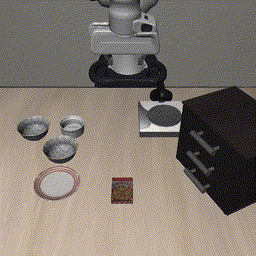

wrist `sample_wrist.png` (256, 256)

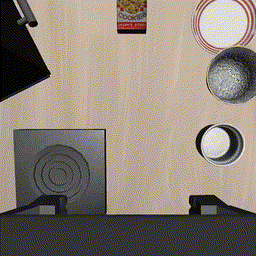

tokenizer ok /workspace/VLA_shopping/demo_sandboxes/rynn_worldvla/weights/Lumina-mGPT-7B-768


In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from IPython.display import display, Markdown
from rynn_turns import RynnSession, load_sample_cameras

third, wrist, third_p, wrist_p = load_sample_cameras()
display(Markdown("**What it sees** (official WorldVLA GIF frame 0 — `pick up the black bowl and place it on the plate`)"))
display(Markdown(f"third `{third_p.name}` {third.size}"))
display(third)
display(Markdown(f"wrist `{wrist_p.name}` {wrist.size}"))
display(wrist)
sess = RynnSession()
print("tokenizer ok", sess._hf_tok_dir)

## Act — official ItemProcessor + `generate_dis_ma`

This card is `ChameleonXLLMXForConditionalGeneration_ck_action_head` (`his_2_third_view_wrist_w_state`, 256). GIF frames have no proprio — act() sends zeros(8) for `<|state|>`.

`load verified … tensors 593` on 2026-09-04 means all 593 Parameters were compared elementwise against the shards + `vqgan.ckpt`. The verified run emitted five `10004`…`15004` chunks ending in `8710` — the trained discrete grammar.

In [2]:
instruction = "pick up the black bowl and place it on the plate"
act = sess.act(third, wrist, instruction)
display(Markdown("**Reply (action tokens)**"))
display(Markdown(act["reply"]))
print(act["think"])

load verified ChameleonXLLMXForConditionalGeneration_ck_action_head tensors 593 shard_bytes 14104373950 vq 129 vq_extra ['model.vqmodel.custom_layer.bias', 'model.vqmodel.custom_layer.weight'] action_head_norm 7.677
VQModel loaded from ../ckpts/chameleon/tokenizer/vqgan.ckpt
[(512, 128), (480, 128), (448, 128), (416, 128), (384, 128), (384, 160), (352, 160), (320, 160), (320, 192), (288, 192), (288, 224), (256, 224), (256, 256), (224, 256), (224, 288), (192, 288), (192, 320), (160, 320), (160, 352), (160, 384), (128, 384), (128, 416), (128, 448), (128, 480), (128, 512)]


**Reply (action tokens)**

5 action chunk(s), 35 bin tokens of 46: [10004, 10157, 10133, 10121, 10110, 10147, 10131, 10006, 15004, 10004, 10176, 10148, 10129, 10110, 10136, 10131, 10006, 15004, 10004, 10198, 10140, 10126, 10106, 10155, 10131, 10006, 15004, 10004, 10204, 10161, 10133, 10097, 10151, 10131, 10006, 15004, 10004, 10234, 10156, 10120, 10098, 10145, 10131, 10006, 15004, 8710]

first env action (7-d): [0.17647055571832637, 4.999999969612645e-09, -0.08823524241948588, -0.00021216873505292, 0.041176456919139404, -0.00044114837153780284, -0.9960784315866849]

{'class': 'ChameleonXLLMXForConditionalGeneration_ck_action_head', 'his': 'his_2_third_view_wrist_w_state', 'n_prompt_tokens': 583, 'produced_ids': [10004, 10157, 10133, 10121, 10110, 10147, 10131, 10006, 15004, 10004, 10176, 10148, 10129, 10110, 10136, 10131, 10006, 15004, 10004, 10198, 10140, 10126, 10106, 10155, 10131, 10006, 15004, 10004, 10204, 10161, 10133, 10097, 10151, 10131, 10006, 15004, 10004, 10234, 10156, 10120, 10098, 10145, 10131, 10006, 15004, 8710], 'n_action_bin_tokens': 35, 'n_chunks': 5, 'state_note': 'dummy zeros(8); GIF frames have no eef/gripper state', 'load': {'ckpt': '/workspace/VLA_shopping/demo_sandboxes/rynn_worldvla/weights/RynnVLA-002/VLA_model_256/libero_goal', 'class': 'ChameleonXLLMXForConditionalGeneration_ck_action_head', 'shards': {'n_tensors': 464, 'n_shards': 3, 'bytes_on_disk': 14104373950, 'index_total_size': 14104320014}, 'vqgan': '/workspace/VLA_shopping/demo_sandboxes/rynn_worldvla/weights/WorldVLA/chameleon/tokenizer/vqgan.ckpt', 'n_vq_tenso

## Dream — 002 trained prompt + VQGAN decode

Prompt is the one the 002 cards were **trained** on (`data/dataset.py`, `world_model_bi_views_conv_generation.py`): `Generate the next image based on the provided sequence of historical images and corresponding actions.<|image|><|image|><|action|>` → two decoded blocks (third, wrist). The vendor eval helper uses an older WorldVLA-era prompt and went off-distribution here. Slow (`max_new_tokens=3000`; needs ~2100 for two 512² frames).

In [3]:
dream = sess.dream(third, wrist, actions_env=act.get("actions_env"))
display(Markdown("**Reply**"))
display(Markdown(dream["reply"]))
print("official script:", dream["official_script"])
print("next_frame:", dream["next_frame"])
print("next_wrist:", dream.get("next_wrist"))
print(dream["think"])

load verified ChameleonXLLMXForConditionalGeneration_ck_action_head tensors 593 shard_bytes 14104373950 vq 129 vq_extra ['model.vqmodel.custom_layer.bias', 'model.vqmodel.custom_layer.weight'] action_head_norm 7.736
VQModel loaded from ../ckpts/chameleon/tokenizer/vqgan.ckpt
[(1024, 256), (992, 256), (960, 256), (928, 256), (896, 256), (896, 288), (864, 288), (832, 288), (800, 288), (800, 320), (768, 320), (736, 320), (736, 352), (704, 352), (672, 352), (672, 384), (640, 384), (608, 384), (608, 416), (576, 416), (576, 448), (544, 448), (544, 480), (512, 480), (512, 512), (480, 512), (480, 544), (448, 544), (448, 576), (416, 576), (416, 608), (384, 608), (384, 640), (384, 672), (352, 672), (352, 704), (352, 736), (320, 736), (320, 768), (320, 800), (288, 800), (288, 832), (288, 864), (288, 896), (256, 896), (256, 928), (256, 960), (256, 992), (256, 1024)]


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:8710 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token.As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


成功提取到两组图像 tokens:
Front image tokens: tensor([ 8197,  8820, 10133,  7879,  4818,  2658,  4983,  4983,    79,  4359,
         5034,  1278,   318,  7668,  2301,  2021,   651,  3255,  4645,  4938,
         3188,  2325,  2927,  4672,  4383,  1657,  1317,  6853,   559,  5034,
         1712,  4215,  1578,    53,  5611,  8113,  6009,  3785,  1298,  2047,
          519,  2424,  1343,  2658,  4384,  1278,  1300,   481,  1201,  7150,
         3399,  4419,  2766,  4661,  4274,  4354,  3819,  6980,  5296,  3033,
         5593,  7288,  3005,  5427,  2371,  2268,  4837,  6111,  6273,  7288,
         7299,   768,  1215,  6762,  1657,  2730,  6695,  5402,   792,    94,
         7649,   705,  4437,  2725,  6252,  5957,   630,  2643,  5430,  2895,
         2707,  4686,  7373,  4784,  8196], device='cuda:0')
Wrist image tokens: tensor([ 8197,  8820, 10133,   685,  4818,  2371,  6669,  1278,  8196],
       device='cuda:0')


UnboundLocalError: cannot access local variable 'g_wrist' where it is not associated with a value

## Talk — leftover BPE (`>= 16384`), image/action ids banned

Think pane = banned-id trace. Verdict `usable` / `garbage` / `empty`.

In [ ]:
talk = sess.talk(third, "What are you looking at, in English?")
display(Markdown("**Think (banned range / ids)**"))
print(talk["think"])
display(Markdown("**Reply**"))
display(Markdown(talk["reply"] or "_(empty)_"))
print("verdict:", talk["verdict"])